# **Import Library**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# **Load Dataset**

In [2]:
dataset = load_dataset("ncduy/mt-en-vi")

train_dataset = dataset["train"].shuffle(seed=42).select(range(25_000))
valid_dataset = dataset["validation"].shuffle(seed=42).select(range(2_000))
test_dataset = dataset["test"].shuffle(seed=42).select(range(2_000))

print(f"Train: {len(train_dataset)}, Validation: {len(valid_dataset)}, Test: {len(test_dataset)}")

README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/597M [00:00<?, ?B/s]

valid.csv:   0%|          | 0.00/2.45M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/2.43M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2884451 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/11316 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11225 [00:00<?, ? examples/s]

Train: 25000, Validation: 2000, Test: 2000


# **EDA**

In [3]:
df = pd.DataFrame(train_dataset)

display(df.head())

,en,vi,source
0,"""education and leading me to providing service...","""nơi giáo dục và dìu dắt tôi để tôi có thể phụ...",OpenSubtitles v2018
1,"Because of the big, bad Fizzle Bomber?",Có phải vì Kẻ Ném Bom Xì Xèo xấu xa?,OpenSubtitles v2018
2,"The author of numerous collections of poems, s...","Là tác giả của nhiều bộ sưu tập thơ, truyện ng...",wikimedia v20210402
3,"R's are less than one, no spread of the disease;","R nhỏ hơn một, không có sự lây truyền bệnh.",QED v2.0a
4,"Well, I'm oversexed... I mean...","À, tôi khát tình... ý tôi là...",OpenSubtitles v2018


In [4]:
print(df.isnull().sum())

# Check duplicates
dup_both = df.duplicated(subset=["en", "vi"]).sum()
dup_en = df.duplicated(subset=["en"]).sum()
dup_vi = df.duplicated(subset=["vi"]).sum()

print(f"Duplicate EN–VI pairs: {dup_both}")
print(f"Duplicate English only: {dup_en}")
print(f"Duplicate Vietnamese only: {dup_vi}")

# Check null or empty values
null_counts = df.isnull().sum()
empty_en = (df["en"].str.strip() == "").sum()
empty_vi = (df["vi"].str.strip() == "").sum()

print(f"\nMissing values:\n{null_counts}")
print(f"Empty English strings: {empty_en}")
print(f"Empty Vietnamese strings: {empty_vi}")

# Count unique values
print(f"\nUnique English sentences: {df['en'].nunique()}")
print(f"Unique Vietnamese sentences: {df['vi'].nunique()}")

en        0
vi        0
source    0
dtype: int64
Duplicate EN–VI pairs: 0
Duplicate English only: 0
Duplicate Vietnamese only: 0

Missing values:
en        0
vi        0
source    0
dtype: int64
Empty English strings: 0
Empty Vietnamese strings: 0

Unique English sentences: 25000
Unique Vietnamese sentences: 25000



English:
min       1.00
10%       5.00
25%       7.00
50%      11.00
75%      18.00
90%      27.00
max     181.00
mean     13.87
Name: en_len, dtype: float64

Vietnamese:
min       2.00
10%       6.00
25%       8.00
50%      13.00
75%      24.00
90%      36.00
max     202.00
mean     18.01
Name: vi_len, dtype: float64


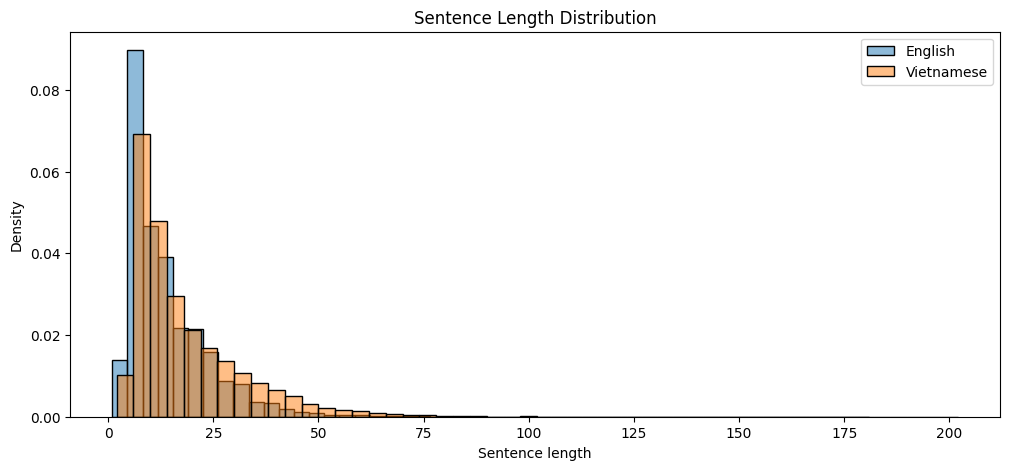

In [5]:
df["en_len"] = df["en"].apply(lambda x: len(x.split()))
df["vi_len"] = df["vi"].apply(lambda x: len(x.split()))

def describe_custom(col):
    desc = col.describe(percentiles=[.1, .25, .5, .75, .9])
    return desc[["min", "10%", "25%", "50%", "75%", "90%", "max", "mean"]].round(2)

print("\nEnglish:")
print(describe_custom(df["en_len"]))

print("\nVietnamese:")
print(describe_custom(df["vi_len"]))

plt.figure(figsize=(12,5))
sns.histplot(df["en_len"], bins=50, stat="density", label="English", alpha=0.5)
sns.histplot(df["vi_len"], bins=50, stat="density", label="Vietnamese", alpha=0.5)
plt.legend()
plt.xlabel("Sentence length")
plt.ylabel("Density")
plt.title("Sentence Length Distribution")
plt.savefig("sentence_length_distribution.png", dpi=300, bbox_inches="tight")
plt.show()